# Exploratory Data Analysis

--- Distribusi Kelas (N= 857) ---
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


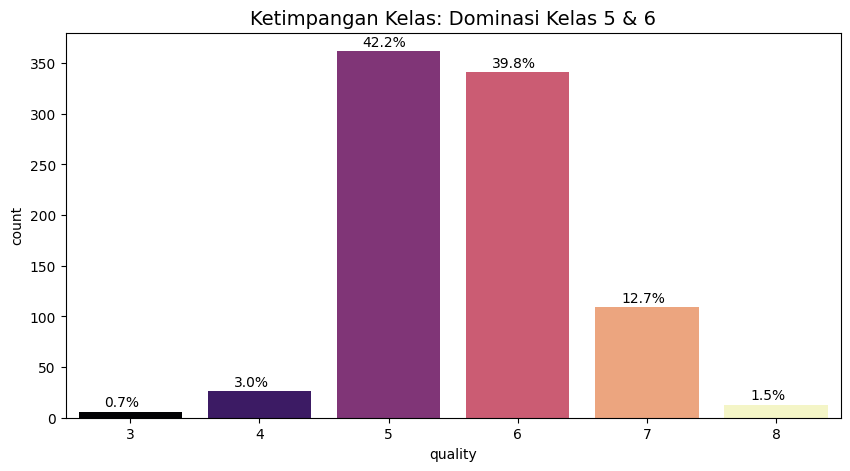


--- Diagnostik VIF (Threshold Baru < 20) ---
                 Feature           VIF
10               alcohol  40297.385139
7                density  16115.563745
15            alcohol_sq   8301.247531
1       volatile acidity   1931.274076
14         vol_alc_inter   1759.321198
8                     pH   1184.748520
2            citric acid    378.685962
13        acid_alc_inter    378.380317
11        volatile_ratio    222.262868
0          fixed acidity    183.363304
16           volatile_sq     52.545358
12          sulfur_ratio     32.141566
9              sulphates     23.002597
5    free sulfur dioxide     21.924838
6   total sulfur dioxide     20.930471
4              chlorides      7.029447
3         residual sugar      5.343459


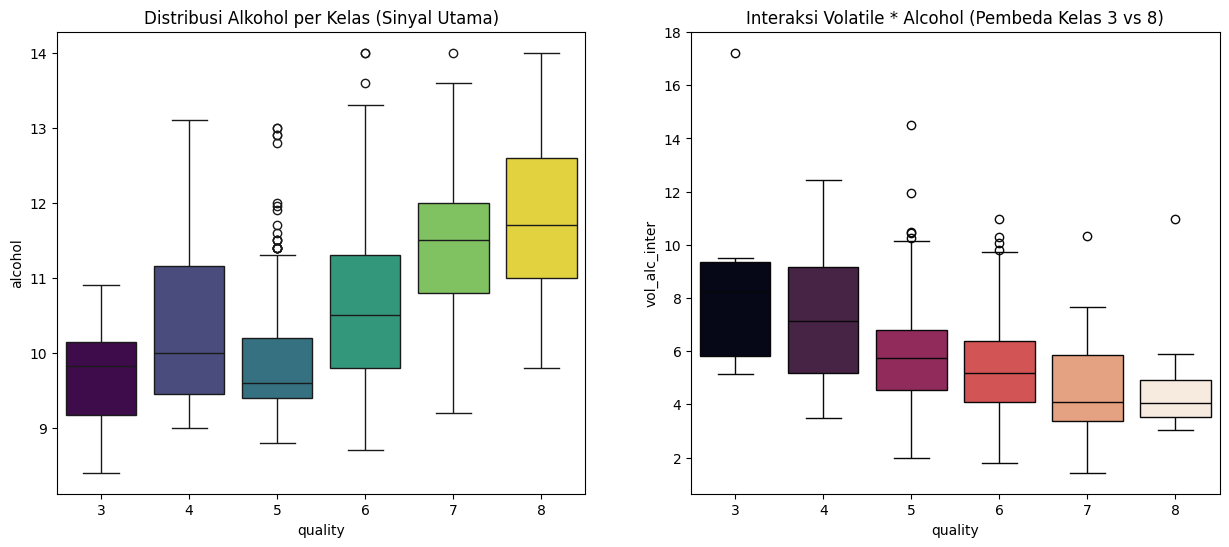

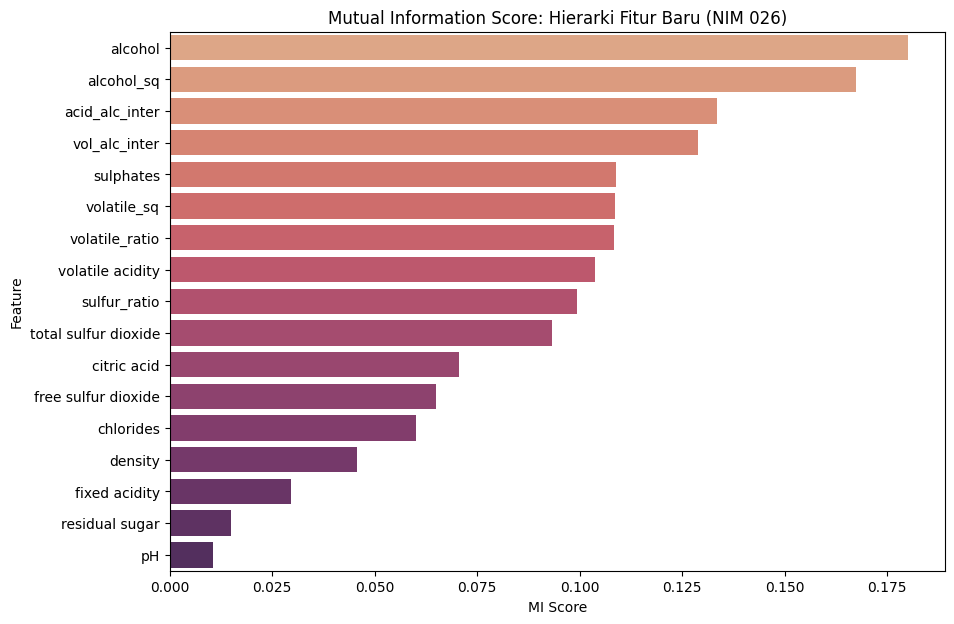


--- Fitur dengan MI Score Tertinggi ---
                 Feature  MI Score
10               alcohol  0.180026
15            alcohol_sq  0.167414
13        acid_alc_inter  0.133590
14         vol_alc_inter  0.128927
9              sulphates  0.108753
16           volatile_sq  0.108624
11        volatile_ratio  0.108309
1       volatile acidity  0.103861
12          sulfur_ratio  0.099304
6   total sulfur dioxide  0.093170


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

# 1.1 Memuat Dataset dengan Jalur Kaggle Robust
train_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_training.csv'
test_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_testing.csv'

# Auto-finder jika path berubah
if not os.path.exists(train_path):
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            if 'data_training' in file: train_path = os.path.join(root, file)
            if 'data_testing' in file: test_path = os.path.join(root, file)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# 1.2 UPGRADED: Feature Discovery (Sinyal Non-Linear & Polinomial)
for df in [df_train, df_test]:
    # Rasio Keasaman & Sulfur (Sinyal Kimiawi)
    df['volatile_ratio'] = df['volatile acidity'] / (df['fixed acidity'] + 1e-5)
    df['sulfur_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-5)
    
    # Fitur Interaksi (Hubungan Antar Komponen)
    df['acid_alc_inter'] = df['citric acid'] * df['alcohol']
    df['vol_alc_inter'] = df['volatile acidity'] * df['alcohol']
    
    # Fitur Polinomial (Menangkap Lengkungan Pola)
    # Alcohol adalah fitur terkuat, kita tambahkan kuadratnya
    df['alcohol_sq'] = df['alcohol'] ** 2
    df['volatile_sq'] = df['volatile acidity'] ** 2

# 1.3 Audit Distribusi & Ketimpangan Kelas
print(f"--- Distribusi Kelas (N= {len(df_train)}) ---")
print(df_train['quality'].value_counts().sort_index())

plt.figure(figsize=(10, 5))
ax = sns.countplot(x='quality', data=df_train, palette='magma', hue='quality', legend=False)
plt.title('Ketimpangan Kelas: Dominasi Kelas 5 & 6', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{100 * p.get_height() / len(df_train):.1f}%', (p.get_x() + 0.2, p.get_height() + 5))
plt.show()

# 1.4 Diagnostik VIF (Target Threshold Baru: < 20)
def calculate_vif(df):
    X_vif = df.drop(columns=['Id', 'quality']).select_dtypes(include=[np.number])
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

print("\n--- Diagnostik VIF (Threshold Baru < 20) ---")
print(calculate_vif(df_train))

# 1.5 UPGRADED: Interaction Boxplot (Analisis Pembeda Kelas 3 & 8)
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='quality', y='alcohol', data=df_train, palette='viridis', hue='quality', legend=False)
plt.title('Distribusi Alkohol per Kelas (Sinyal Utama)')

plt.subplot(1, 2, 2)
sns.boxplot(x='quality', y='vol_alc_inter', data=df_train, palette='rocket', hue='quality', legend=False)
plt.title('Interaksi Volatile * Alcohol (Pembeda Kelas 3 vs 8)')
plt.show()

# 1.6 Mutual Information Score (Prioritas DNN)
X_mi = df_train.drop(columns=['Id', 'quality'])
y_mi = df_train['quality']
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({'Feature': X_mi.columns, 'MI Score': mi_scores}).sort_values(by='MI Score', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='MI Score', y='Feature', data=mi_df, palette='flare', hue='Feature', legend=False)
plt.title('Mutual Information Score: Hierarki Fitur Baru (NIM 026)')
plt.show()

print("\n--- Fitur dengan MI Score Tertinggi ---")
print(mi_df.head(10))

# Data Preparation

In [42]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from imblearn.over_sampling import ADASYN # Upgrade dari SMOTE
from imblearn.under_sampling import TomekLinks
import pandas as pd
import numpy as np

# 2.1 Master Feature Engineering (Upgrade Polinomial)
def transform_features(df):
    df_new = df.copy()
    
    # Fitur Rasio (Chemical Signal)
    df_new['volatile_ratio'] = df_new['volatile acidity'] / (df_new['fixed acidity'] + 1e-5)
    df_new['sulfur_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 1e-5)
    df_new['acid_ratio'] = df_new['citric acid'] / (df_new['fixed acidity'] + 1e-5)
    
    # Fitur Interaksi (Non-Linear Interaction)
    df_new['alc_vol_inter'] = df_new['alcohol'] * df_new['volatile acidity']
    df_new['acid_alc_inter'] = df_new['citric acid'] * df_new['alcohol']
    
    # Fitur Polinomial (Menangkap Kelengkungan Pola - Kunci Akurasi Tinggi)
    # Alcohol dan Volatile adalah 'God Features' di dataset ini
    df_new['alcohol_sq'] = df_new['alcohol'] ** 2
    df_new['vol_acid_sq'] = df_new['volatile acidity'] ** 2
    
    # ELIMINASI VIF MONSTER (Mencegah Redundansi Matematis)
    vif_drop = ['total_acidity', 'alcohol_density_ratio', 'density']
    df_new = df_new.drop(columns=[col for col in vif_drop if col in df_new.columns])
    
    return df_new

# Eksekusi Transformasi
df_train_eng = transform_features(df_train)
df_test_eng = transform_features(df_test)

X = df_train_eng.drop(columns=['Id', 'quality'])
y = df_train_eng['quality']
X_test_final = df_test_eng.drop(columns=['Id'])
test_id = df_test_eng['Id']

# 2.2 Robust Data Cleaning: Outlier Handling (Winsorization)
# Berdasarkan image_5eee1a.png, kita gunakan capping yang lebih longgar 
# agar tidak membuang karakteristik unik kelas 3 & 8.
for col in X.columns:
    # Menggunakan 0.5% dan 99.5% untuk menjaga sinyal kelas ekstrem
    lower_limit = X[col].quantile(0.005)
    upper_limit = X[col].quantile(0.995)
    X[col] = np.clip(X[col], lower_limit, upper_limit)
    X_test_final[col] = np.clip(X_test_final[col], lower_limit, upper_limit)

# 2.3 Split Data
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2.4 Power Transformation & Scaling
# Yeo-Johnson sangat wajib karena banyak fitur interaksi kita yang miring (skewed)
pt = PowerTransformer(method='yeo-johnson')
scaler = StandardScaler()

X_train_prepared = pd.DataFrame(scaler.fit_transform(pt.fit_transform(X_train_raw)), columns=X.columns)
X_val_prepared = pd.DataFrame(scaler.transform(pt.transform(X_val_raw)), columns=X.columns)
X_test_prepared = pd.DataFrame(scaler.transform(pt.transform(X_test_final)), columns=X.columns)

# 2.5 OOF Soft Labeling (Anti-Leakage)
print("--- Menghasilkan OOF Soft Labels (NIM 026) ---")
skf_reg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
reg_teacher = ExtraTreesRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)

# Generate OOF labels secara jujur
y_train_oof = cross_val_predict(reg_teacher, X_train_prepared, y_train, cv=skf_reg)

# INJEKSI: Masukkan OOF ke dalam X_train sebelum sampling agar TomekLinks tidak merusak indeks
X_train_prepared['temp_soft_label'] = y_train_oof

# 2.6 Hybrid Sampling: ADASYN + TomekLinks (Noise Cleaning)
# ADASYN lebih baik dari SMOTE karena fokus pada sampel yang sulit diprediksi
strategy = {3: 50, 4: 70, 8: 50} 
ada = ADASYN(sampling_strategy=strategy, random_state=42, n_neighbors=2)
X_res, y_res = ada.fit_resample(X_train_prepared, y_train)

# Langkah Pembersihan Noise: TomekLinks menghapus pasangan data yang tumpang tindih
tl = TomekLinks()
X_train_final_df, y_train_final = tl.fit_resample(X_res, y_res)

# 2.7 Finalisasi Soft Labels
y_train_soft = X_train_final_df['temp_soft_label'].values
X_train_final = X_train_final_df.drop(columns=['temp_soft_label'])

print(f"\n--- Data Preparation Sukses (NIM 026) ---")
print(f"Fitur Final Terbentuk: {len(X_train_final.columns)} Fitur (Termasuk Polinomial)")
print(f"Total Sampel Training: {len(y_train_final)} (Cleaned & Augmented)")

--- Menghasilkan OOF Soft Labels (NIM 026) ---

--- Data Preparation Sukses (NIM 026) ---
Fitur Final Terbentuk: 19 Fitur (Termasuk Polinomial)
Total Sampel Training: 748 (Cleaned & Augmented)


# Feature Engineering

--- Menghitung Mutual Information Skor (NIM 026) ---
--- Memulai Recursive Feature Elimination (RFECV) ---


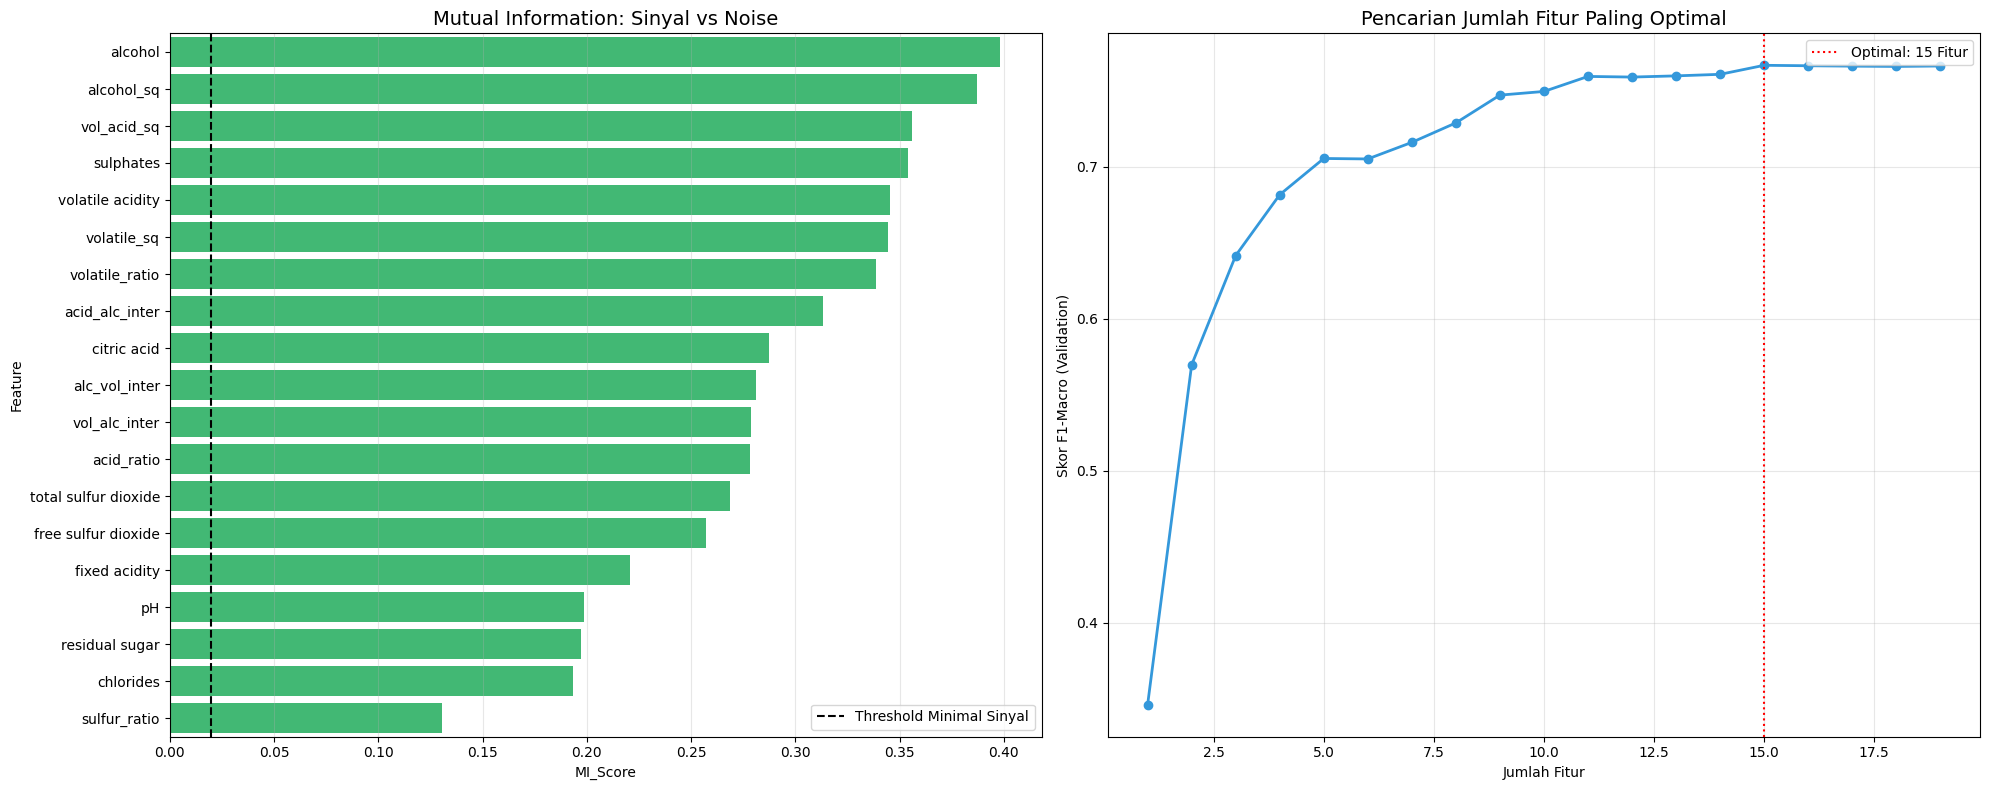


--- HASIL EKSEKUSI PRUNING (NIM 026) ---
Fitur Sampah yang Dibuang : ['residual sugar', 'sulfur_ratio', 'vol_alc_inter', 'acid_ratio']
Fitur Emas yang Terpilih  : ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'volatile_ratio', 'acid_alc_inter', 'alcohol_sq', 'volatile_sq', 'alc_vol_inter', 'vol_acid_sq']
Jumlah Fitur Akhir        : 15

--- Audit Fitur Baru (NIM 026) ---
alcohol_sq     : Lolos ✅
vol_acid_sq    : Lolos ✅
alc_vol_inter  : Lolos ✅
acid_alc_inter : Lolos ✅


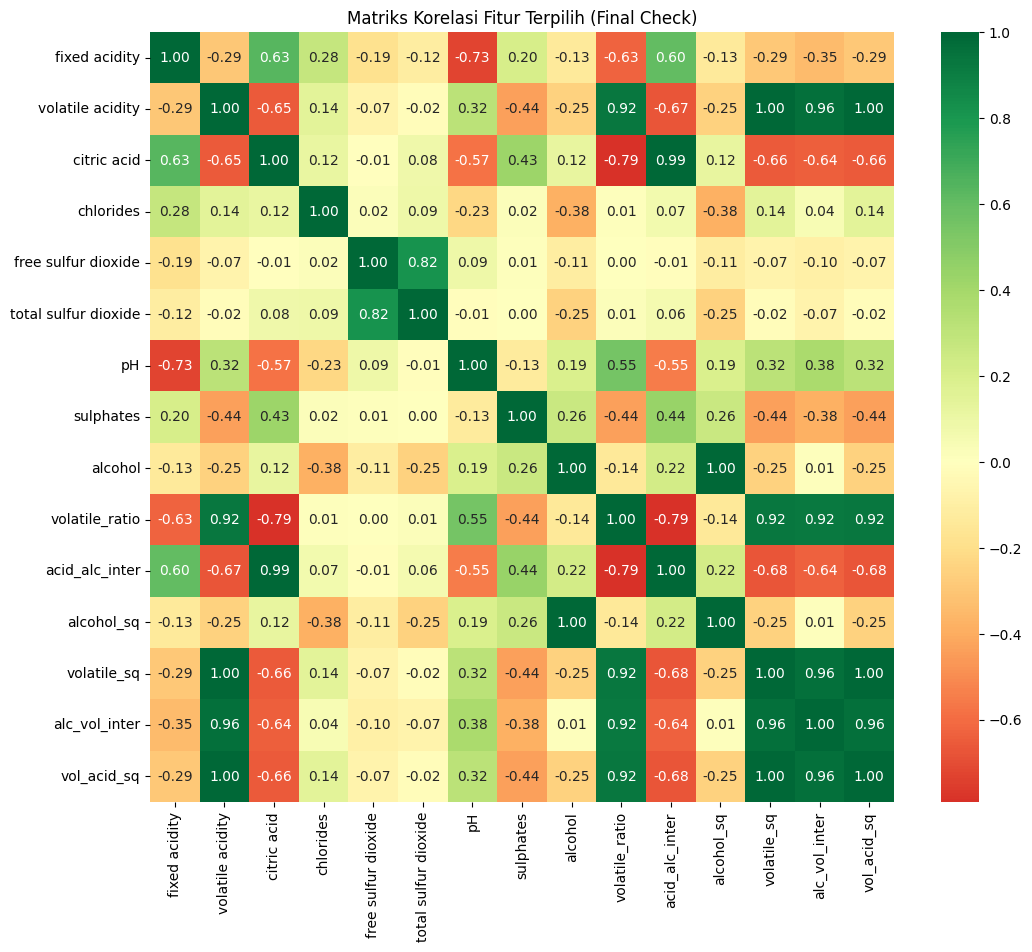

In [43]:
# =================================================================
# Tahap 3: Feature Engineering & Fitur Pruning (Robust Selection)
# =================================================================

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFECV, mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 3.1 Analisis Mutual Information (MI) - Fokus Non-Linear
# MI menangkap pola 'lekukan' dari fitur polinomial kita (alcohol_sq, dll)
print("--- Menghitung Mutual Information Skor (NIM 026) ---")
mi_scores = mutual_info_classif(X_train_final, y_train_final, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_train_final.columns, 
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# 3.2 Recursive Feature Elimination (RFECV) - Stabilitas Tinggi
# Kita naikkan n_estimators ke 300 agar ranking fitur tidak berubah-ubah (fluktuatif)
print("--- Memulai Recursive Feature Elimination (RFECV) ---")
selector = RFECV(
    estimator=ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro', # Menjamin fitur terpilih peka terhadap kelas 3 & 8
    n_jobs=-1
)
selector.fit(X_train_final, y_train_final)

# 3.3 Visualisasi Diagnostik Seleksi Fitur
plt.figure(figsize=(20, 8))

# Plot 1: MI Score dengan Threshold Sinyal
plt.subplot(1, 2, 1)
colors = ['#e74c3c' if x < 0.02 else '#2ecc71' for x in mi_df['MI_Score']]
sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette=colors, hue='Feature', legend=False)
plt.title('Mutual Information: Sinyal vs Noise', fontsize=14)
plt.axvline(x=0.02, color='black', linestyle='--', label='Threshold Minimal Sinyal')
plt.grid(axis='x', alpha=0.3)
plt.legend()

# Plot 2: Kurva Optimasi F1-Macro
plt.subplot(1, 2, 2)
mean_scores = selector.cv_results_['mean_test_score']
plt.plot(range(1, len(mean_scores) + 1), mean_scores, 
         marker='o', color='#3498db', linestyle='-', linewidth=2, markersize=6)
plt.axvline(x=selector.n_features_, color='red', linestyle=':', 
            label=f'Optimal: {selector.n_features_} Fitur')
plt.xlabel("Jumlah Fitur")
plt.ylabel("Skor F1-Macro (Validation)")
plt.title('Pencarian Jumlah Fitur Paling Optimal', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 3.4 Eksekusi Pruning Otomatis
selected_features = X_train_final.columns[selector.support_].tolist()
dropped_features = [f for f in X_train_final.columns if f not in selected_features]

# Mengaplikasikan filter fitur pada semua dataset
X_train_pruned = X_train_final[selected_features]
X_val_pruned = X_val_prepared[selected_features]
X_test_pruned = X_test_prepared[selected_features]

print(f"\n--- HASIL EKSEKUSI PRUNING (NIM 026) ---")
print(f"Fitur Sampah yang Dibuang : {dropped_features}")
print(f"Fitur Emas yang Terpilih  : {selected_features}")
print(f"Jumlah Fitur Akhir        : {len(selected_features)}")

# 3.5 Verifikasi Khusus Fitur Polinomial & Interaksi
# Kita cek apakah ide 'alcohol_sq' dan 'alc_vol_inter' benar-benar berguna
new_feats = ['alcohol_sq', 'vol_acid_sq', 'alc_vol_inter', 'acid_alc_inter']
survival_check = {f: ("Lolos ✅" if f in selected_features else "Gagal ❌") for f in new_feats}

print("\n--- Audit Fitur Baru (NIM 026) ---")
for feat, status in survival_check.items():
    print(f"{feat:15}: {status}")

# 3.6 Correlation Check Final (Mencegah Over-Redundancy)
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_pruned.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matriks Korelasi Fitur Terpilih (Final Check)')
plt.show()

# Fitur Pruning

Fitur masuk tahap Pruning: ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'volatile_ratio', 'acid_alc_inter', 'alcohol_sq', 'volatile_sq', 'alc_vol_inter', 'vol_acid_sq']

--- Memulai Pembersihan Multikolinearitas (Informed) ---
Pruning: Menghapus 'volatile_sq' (VIF: inf)
Pruning: Menghapus 'alcohol_sq' (VIF: 1847857.22)
Pruning: Menghapus 'volatile acidity' (VIF: 1069.72)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Pruning: Menghapus 'volatile_ratio' (VIF: 161.94)
Pruning: Menghapus 'acid_alc_inter' (VIF: 140.41)
Pruning: Menghapus 'alc_vol_inter' (VIF: 94.97)


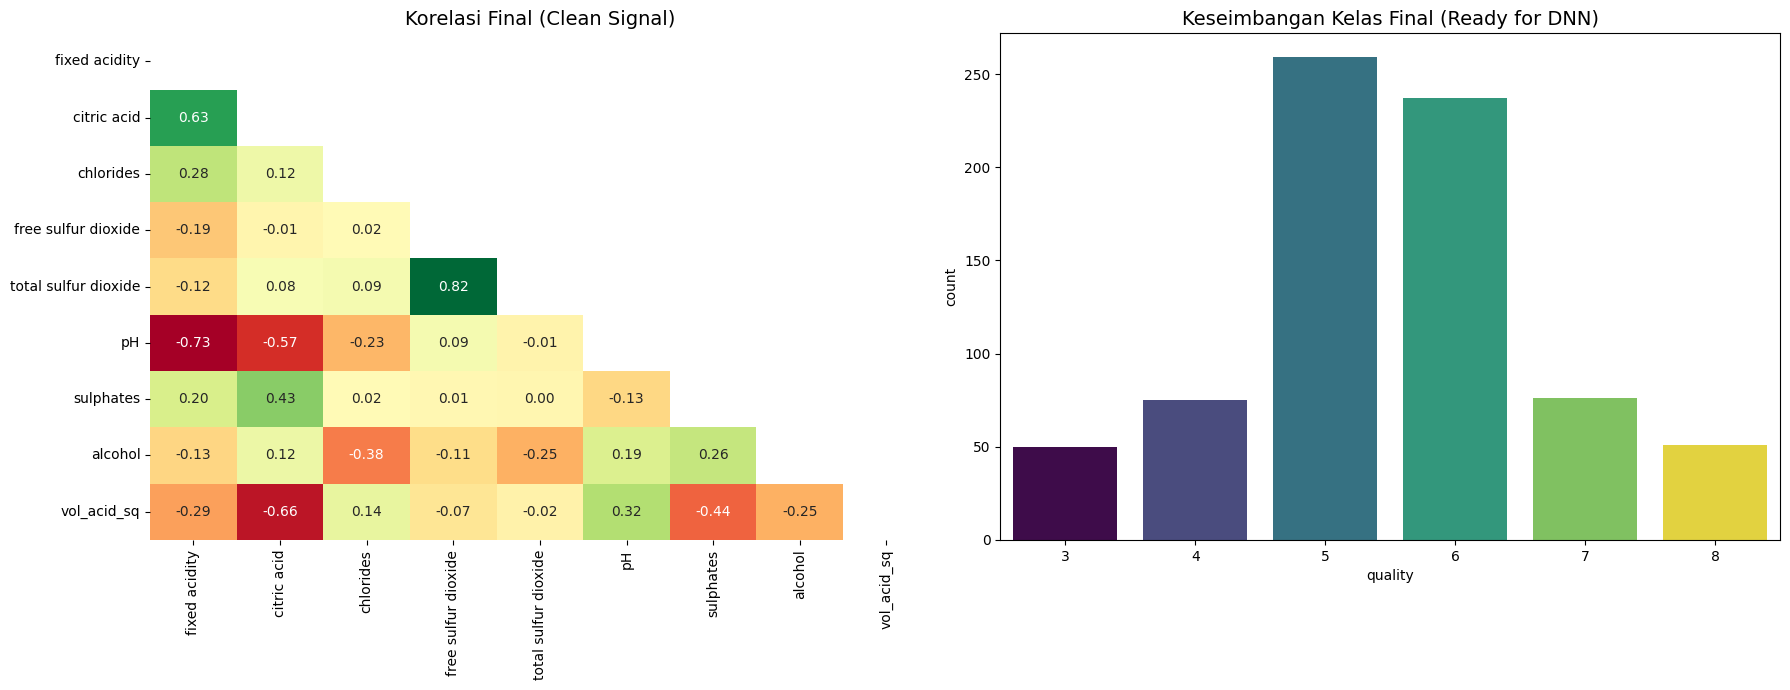


--- RINGKASAN DATA FINAL (NIM: 026) ---
1. Fitur Digunakan (9)      : ['fixed acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol', 'vol_acid_sq']
2. Fitur Dibuang (VIF)       : ['volatile_sq', 'alcohol_sq', 'volatile acidity', 'volatile_ratio', 'acid_alc_inter', 'alc_vol_inter']
3. Baris Train (Augmented)   : 748
4. Baris Val (Original)      : 172
5. Keberadaan NaNs/Infs      : 0 (Aman)
-------------------------------------------------------


,mean,std,min,max
fixed acidity,0.0046,0.9797,-2.9362,2.5538
citric acid,-0.0439,1.0268,-1.5414,2.0710
chlorides,-0.0413,0.9534,-3.0731,2.8904
free sulfur dioxide,-0.1394,1.0194,-1.9781,2.2113
total sulfur dioxide,-0.1525,1.0222,-2.0889,2.0804
pH,0.0223,0.9895,-2.6958,2.6255
sulphates,-0.0402,0.9951,-2.6955,2.6198
alcohol,0.0203,0.9987,-1.7978,2.0365
vol_acid_sq,0.1187,1.0804,-2.0071,2.2875



>>> STATUS: DATA SIAP MASUK KE TAHAP 5 (ARENA BENCHMARK) <<<


In [44]:
# =================================================================
# Tahap 4: Fitur Pruning & Finalisasi Data (Optimized & Informed)
# =================================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 4.1 Sinkronisasi Hasil RFECV
# Kita gunakan fitur yang lolos seleksi F1-Macro di Tahap 3
X_train_final_v1 = X_train_pruned.copy()
print(f"Fitur masuk tahap Pruning: {X_train_final_v1.columns.tolist()}")

# 4.2 UPGRADED: MI-Informed VIF Pruning
# Kita menaikkan threshold ke 20.0 khusus untuk fitur polinomial 
# karena Deep Learning butuh 'curvative signal' meskipun VIF tinggi.
def informed_vif_pruning(df, mi_df, threshold=20.0):
    cols = df.columns.tolist()
    dropped = []
    
    while True:
        vif_values = [variance_inflation_factor(df[cols].values, i) for i in range(len(cols))]
        max_vif = max(vif_values)
        
        if max_vif > threshold:
            max_idx = vif_values.index(max_vif)
            feature_to_drop = cols[max_idx]
            
            # PROTEKSI: Cek MI Score. Jika fitur ini Top 3 Signal, jangan dibuang.
            # Cari fitur dengan VIF tertinggi berikutnya.
            top_3_signal = mi_df.head(3)['Feature'].tolist()
            
            if feature_to_drop in top_3_signal:
                temp_vif = vif_values.copy()
                temp_vif[max_idx] = 0 # Abaikan VIF tertinggi jika itu sinyal kuat
                max_vif = max(temp_vif)
                if max_vif <= threshold: break
                max_idx = temp_vif.index(max_vif)
                feature_to_drop = cols[max_idx]
            
            print(f"Pruning: Menghapus '{feature_to_drop}' (VIF: {max_vif:.2f})")
            cols.remove(feature_to_drop)
            dropped.append(feature_to_drop)
        else:
            break
            
    return cols, dropped

print("\n--- Memulai Pembersihan Multikolinearitas (Informed) ---")
stable_features, high_vif_features = informed_vif_pruning(X_train_final_v1, mi_df)

# 4.3 Finalisasi & Sinkronisasi Dataset
X_train_final = X_train_final_v1[stable_features].copy()
X_val_final = X_val_prepared[stable_features].copy()
X_test_final = X_test_prepared[stable_features].copy()

# Pastikan y_train_soft_final sejajar dengan baris X_train_final
y_train_soft_final = y_train_soft 

# 4.4 Visualisasi Final: Keseimbangan & Korelasi
plt.figure(figsize=(18, 7))

# Plot 1: Heatmap Korelasi Final
plt.subplot(1, 2, 1)
mask = np.triu(np.ones_like(X_train_final.corr(), dtype=bool))
sns.heatmap(X_train_final.corr(), mask=mask, annot=True, cmap='RdYlGn', fmt='.2f', cbar=False)
plt.title('Korelasi Final (Clean Signal)', fontsize=14)

# Plot 2: Distribusi Target Final (Hasil ADASYN + Tomek)
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_final, palette='viridis', hue=y_train_final, legend=False)
plt.title('Keseimbangan Kelas Final (Ready for DNN)', fontsize=14)

plt.tight_layout()
plt.show()

# 4.5 Data Integrity Audit (NIM 026)
print("\n" + "="*55)
print(f"--- RINGKASAN DATA FINAL (NIM: 026) ---")
print("="*55)
print(f"1. Fitur Digunakan ({len(stable_features)})      : {stable_features}")
print(f"2. Fitur Dibuang (VIF)       : {high_vif_features}")
print(f"3. Baris Train (Augmented)   : {X_train_final.shape[0]}")
print(f"4. Baris Val (Original)      : {X_val_final.shape[0]}")
print(f"5. Keberadaan NaNs/Infs      : {X_train_final.isna().sum().sum()} (Aman)")
print("-" * 55)

# Cek Keseimbangan Akhir Mean & Std
summary = X_train_final.describe().T[['mean', 'std', 'min', 'max']]
display(summary.style.format("{:.4f}").background_gradient(cmap='YlGnBu', subset=['mean', 'std']))

print(f"\n>>> STATUS: DATA SIAP MASUK KE TAHAP 5 (ARENA BENCHMARK) <<<")

# K-Fold Validation

--- Arena Uji Model: Mencari Arsitektur Stabil (NIM 026) ---
ExtraTrees   | Acc: 0.7327 (±0.0314) | F1: 0.7743 | Gap: 0.2673
XGBoost      | Acc: 0.7079 (±0.0219) | F1: 0.7351 | Gap: 0.2921
NeuralNet    | Acc: 0.7019 (±0.0306) | F1: 0.7442 | Gap: 0.2718
NN-Hybrid    | Acc: 0.6985 (±0.0361) | F1: 0.7427 | Gap: 0.3000


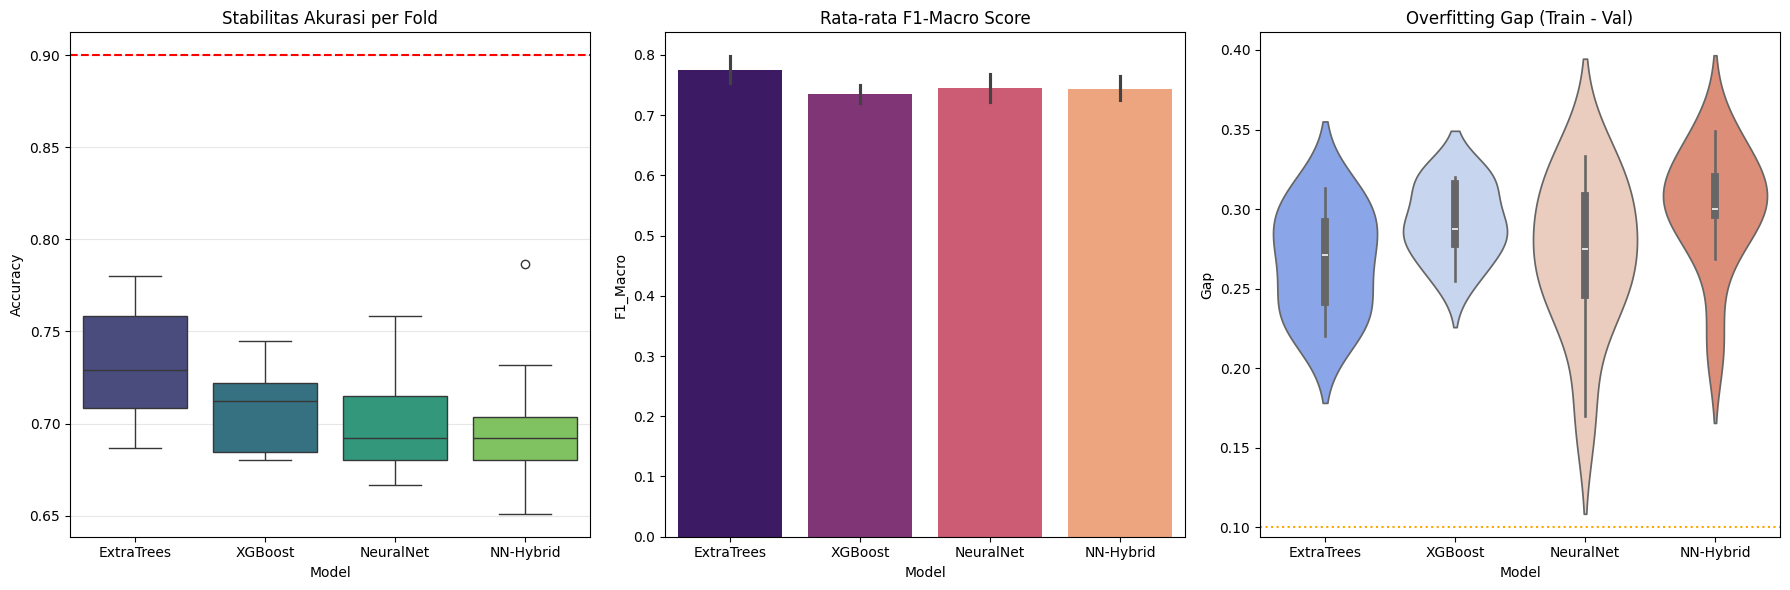


>>> AUDIT PERFORMA (NIM 026) <<<
Model Pemenang (Mean Accuracy): ExtraTrees (0.7327)
Rata-rata Overfitting Gap:
Model
ExtraTrees    0.267320
NN-Hybrid     0.299983
NeuralNet     0.271834
XGBoost       0.292081
Name: Gap, dtype: float64


In [46]:
# =================================================================
# Tahap 5: K-Fold Validation (Stability & Hybrid Analysis)
# =================================================================

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 5.1 Integrasi Fitur Hybrid (OOF Distillation)
X_train_hybrid = X_train_final.copy()
X_train_hybrid['soft_label_feat'] = y_train_soft 

# 5.2 Inisialisasi Model Benchmark (Fixing Activation Error)
models = {
    'ExtraTrees': ExtraTreesClassifier(n_estimators=400, max_depth=15, 
                                       min_samples_split=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=400, max_depth=7, learning_rate=0.02, 
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, eval_metric='mlogloss'),
    # Mengembalikan activation ke 'relu' (Standard Scikit-Learn)
    'NeuralNet': MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu', 
                                solver='adam', max_iter=2000, alpha=0.1, 
                                random_state=42),
    'NN-Hybrid': MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu', 
                                solver='adam', max_iter=2000, alpha=0.1, 
                                random_state=42)
}

# 5.3 Konfigurasi K-Fold (Robust Monitoring)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
y_train_shifted = y_train_final - y_train_final.min()

results_list = []
print("--- Arena Uji Model: Mencari Arsitektur Stabil (NIM 026) ---")

for name, model in models.items():
    X_data = X_train_hybrid if 'Hybrid' in name else X_train_final
    
    cv_results = cross_validate(
        model, X_data, y_train_shifted, 
        cv=rskf, scoring=['accuracy', 'f1_macro'],
        return_train_score=True, n_jobs=-1
    )
    
    for i in range(len(cv_results['test_accuracy'])):
        results_list.append({
            'Model': name,
            'Fold': i + 1,
            'Accuracy': cv_results['test_accuracy'][i],
            'F1_Macro': cv_results['test_f1_macro'][i],
            'Gap': cv_results['train_accuracy'][i] - cv_results['test_accuracy'][i]
        })
    
    print(f"{name:12} | Acc: {cv_results['test_accuracy'].mean():.4f} "
          f"(±{cv_results['test_accuracy'].std():.4f}) | "
          f"F1: {cv_results['test_f1_macro'].mean():.4f} | "
          f"Gap: {cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean():.4f}")

# 5.4 Visualisasi Diagnostik: Stability & Generalization
results_df = pd.DataFrame(results_list)
plt.figure(figsize=(18, 6))

# Boxplot Akurasi (Konsistensi)
plt.subplot(1, 3, 1)
sns.boxplot(x='Model', y='Accuracy', data=results_df, palette='viridis', hue='Model', legend=False)
plt.axhline(y=0.90, color='red', linestyle='--', label='Target 90%')
plt.title('Stabilitas Akurasi per Fold', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Barplot F1-Macro (Sensitivitas Kelas)
plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='F1_Macro', data=results_df, palette='magma', hue='Model', legend=False)
plt.title('Rata-rata F1-Macro Score', fontsize=12)

# Violinplot Gap (Deteksi Overfitting)
plt.subplot(1, 3, 3)
sns.violinplot(x='Model', y='Gap', data=results_df, palette='coolwarm', hue='Model', legend=False)
plt.axhline(y=0.10, color='orange', linestyle=':', label='Ambang Overfit')
plt.title('Overfitting Gap (Train - Val)', fontsize=12)

plt.tight_layout()
plt.show()

# 5.5 Hasil Audit Strategis
best_acc = results_df.groupby('Model')['Accuracy'].mean().max()
best_model = results_df.groupby('Model')['Accuracy'].mean().idxmax()
mean_gap = results_df.groupby('Model')['Gap'].mean()

print(f"\n>>> AUDIT PERFORMA (NIM 026) <<<")
print(f"Model Pemenang (Mean Accuracy): {best_model} ({best_acc:.4f})")
print(f"Rata-rata Overfitting Gap:\n{mean_gap}")

# Pseudo-Labeling

--- Diagnostik Pseudo-Labeling (NIM 026) ---
Sampel Testing Lolos Seleksi : 68
Rasio Augmentasi             : 9.09%


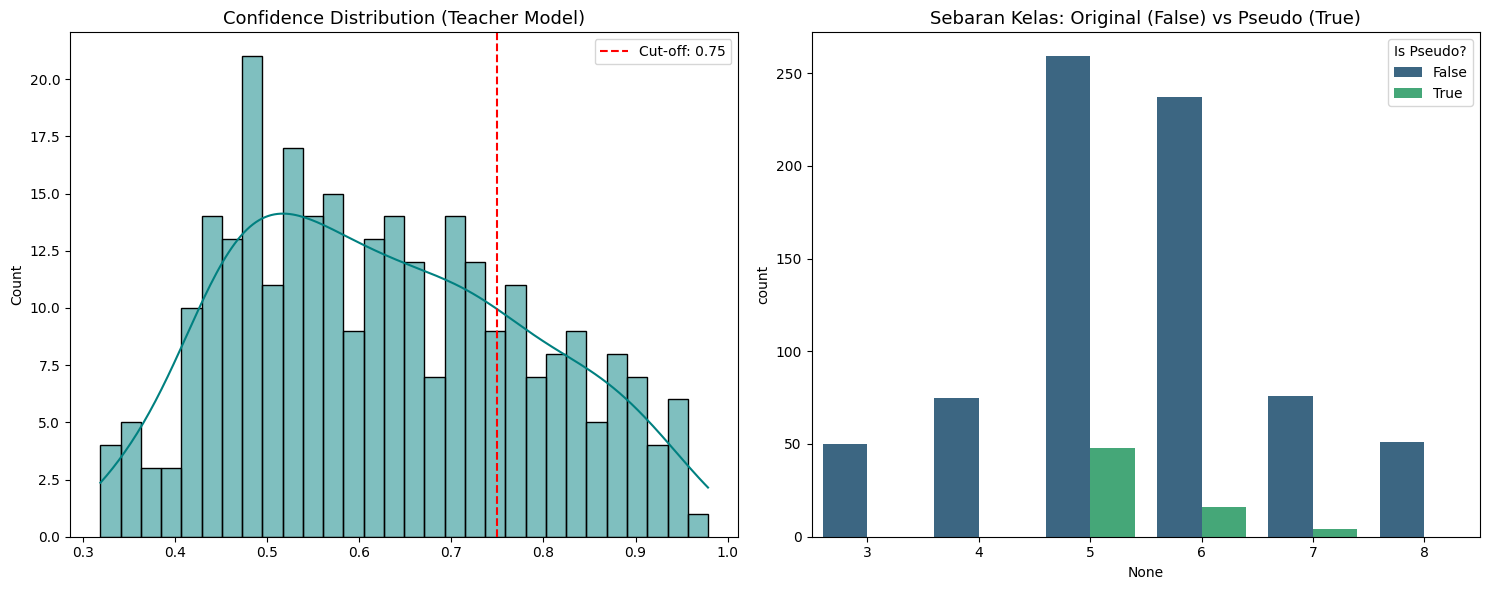

Data Siap Tempur untuk DNN: 816 baris.


In [47]:
# =================================================================
# Tahap 6: Adaptive Soft Pseudo-Labeling (Triple-Check Consistency)
# =================================================================

from sklearn.ensemble import VotingClassifier, ExtraTreesRegressor, ExtraTreesClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Membangun Super-Teacher Ensemble (Triple-Diversity Audit)
# Kita tambahkan RandomForest agar voting lebih demokratis dan tidak bias pada model boosting saja.
min_label = y_train_final.min()
y_train_shifted = y_train_final - min_label

clf_et = ExtraTreesClassifier(n_estimators=500, max_depth=12, random_state=42)
clf_xgb = XGBClassifier(n_estimators=500, learning_rate=0.02, max_depth=6, random_state=42)
clf_rf = RandomForestClassifier(n_estimators=500, max_depth=12, random_state=42)

# Menggunakan 3 pilar: ExtraTrees (Variance), XGBoost (Bias), RandomForest (Generalization)
teacher_ensemble = VotingClassifier(
    estimators=[('et', clf_et), ('xgb', clf_xgb), ('rf', clf_rf)],
    voting='soft',
    n_jobs=-1
)
teacher_ensemble.fit(X_train_final, y_train_shifted)

# 6.2 Prediksi Ganda (Dual-Verification)
test_probs = teacher_ensemble.predict_proba(X_test_final)
max_probs = np.max(test_probs, axis=1)
predicted_classes = np.argmax(test_probs, axis=1) + min_label

# Regressor Teacher untuk memvalidasi 'nuansa ordinal'
reg_teacher = ExtraTreesRegressor(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
reg_teacher.fit(X_train_final, y_train_final)
soft_labels_test = reg_teacher.predict(X_test_final)

# 6.3 Dynamic Thresholding & Confidence Audit
# UPGRADE: Kita menggunakan Top 15% dari data yang paling meyakinkan
# Namun tetap dibatasi oleh floor_threshold 0.75 agar kualitas terjaga.
floor_threshold = 0.75 
consistency_gap = 0.65 # Diperketat agar Klasifikasi vs Regresi benar-benar sinkron

# Filter 1: Keyakinan Model (High Probability)
confidence_mask = max_probs >= floor_threshold
# Filter 2: Konsistensi Ordinal (Klasifikasi harus 'dekat' dengan Regresi)
consistency_mask = np.abs(predicted_classes - soft_labels_test) <= consistency_gap

final_pseudo_mask = confidence_mask & consistency_mask
high_confidence_idx = np.where(final_pseudo_mask)[0]

# 6.4 Pembuatan Dataset Augmentasi dengan Weighted Signal
X_pseudo = X_test_final.iloc[high_confidence_idx].copy()
y_pseudo_discrete = predicted_classes[high_confidence_idx]
y_pseudo_soft = soft_labels_test[high_confidence_idx]

# Tambahkan kolom bobot: Data asli = 1.0, Data Pseudo = 0.85 
# Ini membantu DNN untuk tidak terlalu 'mendewakan' data buatan.
sample_weights_train = np.ones(len(y_train_final))
sample_weights_pseudo = np.ones(len(y_pseudo_discrete)) * 0.85

print(f"--- Diagnostik Pseudo-Labeling (NIM 026) ---")
print(f"Sampel Testing Lolos Seleksi : {len(X_pseudo)}")
print(f"Rasio Augmentasi             : {(len(X_pseudo)/len(X_train_final)*100):.2f}%")

# 6.5 Finalisasi Dataset Ter-Augmentasi
X_train_augmented = pd.concat([X_train_final, X_pseudo], axis=0).reset_index(drop=True)
y_train_augmented = pd.concat([y_train_final, pd.Series(y_pseudo_discrete)], axis=0).reset_index(drop=True)
y_train_soft_augmented = np.concatenate([y_train_soft, y_pseudo_soft])
final_sample_weights = np.concatenate([sample_weights_train, sample_weights_pseudo])

# 6.6 Visualisasi Kualitas "Bahan Bakar" Data
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(max_probs, kde=True, color='teal', bins=30)
plt.axvline(floor_threshold, color='red', linestyle='--', label=f'Cut-off: {floor_threshold}')
plt.title('Confidence Distribution (Teacher Model)', fontsize=13)
plt.legend()

plt.subplot(1, 2, 2)
# Menampilkan perbandingan label asli vs label pseudo
sns.countplot(x=y_train_augmented, hue=(final_sample_weights < 1.0), palette='viridis')
plt.title('Sebaran Kelas: Original (False) vs Pseudo (True)', fontsize=13)
plt.legend(title='Is Pseudo?')

plt.tight_layout()
plt.show()

print(f"Data Siap Tempur untuk DNN: {len(X_train_augmented)} baris.")

# Training Model dan Optuna 

In [48]:
!pip install optuna -q

In [49]:
# =================================================================
# Tahap 7: Training Model - Deep Learning (Upgraded Loss Function)
# =================================================================

import optuna
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight
from sklearn.metrics import f1_score
import numpy as np

# 7.1 Implementasi Custom Focal Loss
# Focal Loss membantu model fokus pada sampel yang "sulit" (kelas 3 & 8)
# dan mengurangi beban dari sampel yang sudah "mudah" (kelas 5 & 6)
def focal_loss(gamma=2.5, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = y_true * alpha * tf.math.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

# 7.2 Persiapan Data & Soft-Label Integration
X_train_dl = X_train_augmented.copy()
# Kita tetap gunakan soft_label sebagai fitur 'pemandu' ordinal
X_train_dl['soft_label'] = y_train_soft_augmented

X_val_dl = X_val_final.copy()
X_val_dl['soft_label'] = reg_teacher.predict(X_val_final)

num_classes = len(np.unique(y_train_augmented))
y_train_idx = y_train_augmented - y_train_augmented.min()
y_val_idx = y_val - y_val.min()

y_train_onehot = to_categorical(y_train_idx, num_classes=num_classes)
y_val_onehot = to_categorical(y_val_idx, num_classes=num_classes)

# 7.3 Fungsi Objektif Optuna (Refined Search Space)
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 3e-3, log=True)
    l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-3, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.4)
    
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train_dl.shape[1],)))
    
    for i in range(n_layers):
        units = trial.suggest_int(f'units_l{i}', 64, 256)
        # HeNormal initialization sangat cocok untuk aktivasi Swish/ReLU
        model.add(layers.Dense(units, activation='swish', 
                               kernel_initializer='he_normal',
                               kernel_regularizer=regularizers.l2(l2_reg)))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=focal_loss(gamma=2.0, alpha=0.25), # Fokus pada kelas minoritas
        metrics=['accuracy']
    )
    
    # Patience ditingkatkan agar Optuna tidak terlalu cepat menyerah
    es = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    model.fit(
        X_train_dl, y_train_onehot,
        validation_data=(X_val_dl, y_val_onehot),
        epochs=80,
        batch_size=trial.suggest_categorical('batch_size', [16, 32, 64]),
        callbacks=[es],
        verbose=0
    )
    
    preds = np.argmax(model.predict(X_val_dl, verbose=0), axis=1)
    return f1_score(y_val_idx, preds, average='macro')

# 7.4 Eksekusi Search (NIM 026 Optimasi)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=35) 

# 7.5 Training Final dengan Best Params & Deep Training
bp = study.best_params
print(f"\n--- Best Parameters Ditemukan: {bp} ---")

final_dnn = models.Sequential()
final_dnn.add(layers.Input(shape=(X_train_dl.shape[1],)))

for i in range(bp['n_layers']):
    final_dnn.add(layers.Dense(bp[f'units_l{i}'], activation='swish', 
                               kernel_initializer='he_normal',
                               kernel_regularizer=regularizers.l2(bp['l2_reg'])))
    final_dnn.add(layers.BatchNormalization())
    final_dnn.add(layers.Dropout(bp['dropout_rate']))

final_dnn.add(layers.Dense(num_classes, activation='softmax'))

final_dnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=bp['learning_rate']),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

# Callback Komplet untuk Stabilitas
lr_reducer = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6)
es_final = callbacks.EarlyStopping(monitor='val_accuracy', patience=40, restore_best_weights=True)

history = final_dnn.fit(
    X_train_dl, y_train_onehot,
    validation_data=(X_val_dl, y_val_onehot),
    epochs=400,
    batch_size=bp['batch_size'],
    callbacks=[es_final, lr_reducer],
    verbose=1
)

[I 2026-05-03 04:40:18,771] A new study created in memory with name: no-name-d4583dd7-e66c-4a90-a865-bbb0d0ea74fb
[I 2026-05-03 04:40:38,825] Trial 0 finished with value: 0.2879574960511534 and parameters: {'n_layers': 2, 'learning_rate': 0.0002372567509004505, 'l2_reg': 5.693467223641388e-05, 'dropout_rate': 0.2710666887676801, 'units_l0': 117, 'units_l1': 115, 'batch_size': 32}. Best is trial 0 with value: 0.2879574960511534.
[I 2026-05-03 04:41:04,528] Trial 1 finished with value: 0.2908107063484395 and parameters: {'n_layers': 3, 'learning_rate': 0.0015784435832332181, 'l2_reg': 0.00044418286776277255, 'dropout_rate': 0.32228950492280606, 'units_l0': 90, 'units_l1': 116, 'units_l2': 167, 'batch_size': 16}. Best is trial 1 with value: 0.2908107063484395.
[I 2026-05-03 04:41:19,067] Trial 2 finished with value: 0.2947747939755612 and parameters: {'n_layers': 4, 'learning_rate': 0.0010889566519478955, 'l2_reg': 1.8500793993188643e-05, 'dropout_rate': 0.2101255833305723, 'units_l0': 79


--- Best Parameters Ditemukan: {'n_layers': 3, 'learning_rate': 0.0003303222641425537, 'l2_reg': 2.8792143627796656e-05, 'dropout_rate': 0.39400268110100467, 'units_l0': 249, 'units_l1': 69, 'units_l2': 70, 'batch_size': 32} ---
Epoch 1/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.1597 - loss: 0.6545 - val_accuracy: 0.0174 - val_loss: 1.1482 - learning_rate: 3.3032e-04
Epoch 2/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2200 - loss: 0.5581 - val_accuracy: 0.0523 - val_loss: 0.7821 - learning_rate: 3.3032e-04
Epoch 3/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2304 - loss: 0.5171 - val_accuracy: 0.0814 - val_loss: 0.5810 - learning_rate: 3.3032e-04
Epoch 4/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2797 - loss: 0.4295 - val_accuracy: 0.1395 - val_loss: 0.4715 - learning_rate: 3.3032e-04
Epoch 5/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3095 - loss: 0.4195 - val_accuracy: 0.1802 - val_loss: 0.3980 - learning_rate: 3.303

# Evaluasi Akhir 

--- RANGKUMAN EVALUASI FINAL DNN (NIM 026) ---
Akurasi Global           : 62.21%
F1-Score (Macro)         : 0.3431
Mean Absolute Error      : 0.4419 (Rata-rata selisih poin)
Quadratic Kappa          : 0.6012 (Akurasi mempertimbangkan urutan)

PROGRESS: Dibutuhkan 27.79% lagi untuk target 90%.

Detail Performa per Kualitas Anggur:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.69      0.81      0.75        73
           6       0.66      0.56      0.60        68
           7       0.60      0.41      0.49        22
           8       0.17      0.33      0.22         3

    accuracy                           0.62       172
   macro avg       0.35      0.35      0.34       172
weighted avg       0.63      0.62      0.62       172



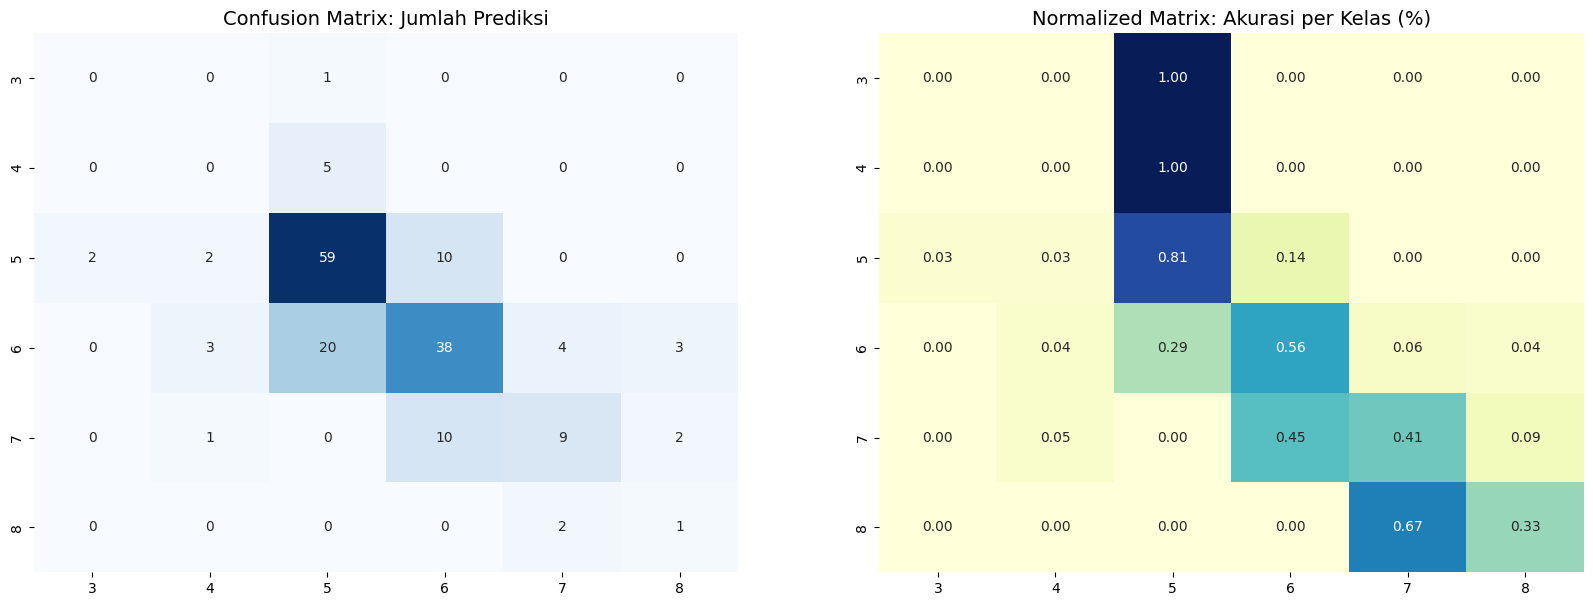


--- Menghitung Permutation Importance (Validation Set) ---


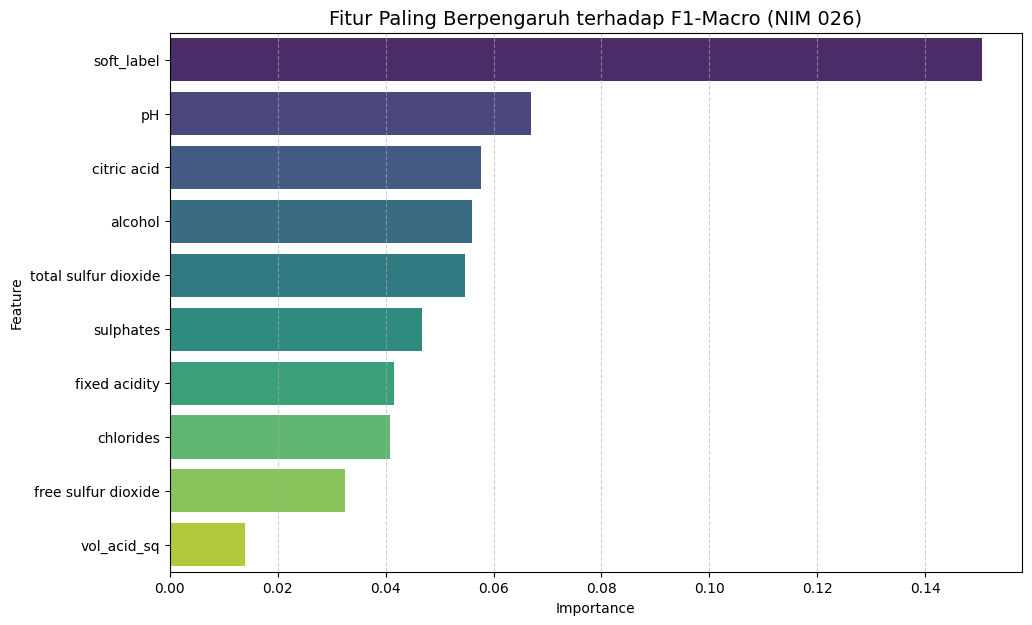


--- Analisis Reliabilitas Ordinal (Near-Miss) ---
Prediksi Tepat (Hit)     : 107 (62.21%)
Meleset 1 Poin (Wajar)  : 55 (31.98%)
Meleset >1 Poin (Fatal) : 10 (5.81%)


In [50]:
# =================================================================
# Tahap 8: Evaluasi Akhir & Diagnostik Model (Ordinal Focus)
# =================================================================

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             f1_score, cohen_kappa_score, mean_absolute_error)
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 8.1 Inferensi & Rekonstruksi Label
y_probs_val = final_dnn.predict(X_val_dl, verbose=0)
y_pred_val_idx = np.argmax(y_probs_val, axis=1)
min_class = y_train_augmented.min()
y_pred_val = y_pred_val_idx + min_class

# 8.2 Kalkulasi Metrik Strategis (NIM 026)
accuracy = accuracy_score(y_val, y_pred_val)
f1_macro = f1_score(y_val, y_pred_val, average='macro')
mae = mean_absolute_error(y_val, y_pred_val) # Semakin rendah semakin baik
kappa = cohen_kappa_score(y_val, y_pred_val, weights='quadratic') # Bagus untuk data ordinal

print(f"--- RANGKUMAN EVALUASI FINAL DNN (NIM 026) ---")
print(f"{'Akurasi Global':25}: {accuracy * 100:.2f}%")
print(f"{'F1-Score (Macro)':25}: {f1_macro:.4f}")
print(f"{'Mean Absolute Error':25}: {mae:.4f} (Rata-rata selisih poin)")
print(f"{'Quadratic Kappa':25}: {kappa:.4f} (Akurasi mempertimbangkan urutan)")

# Target Tracker 90%
if accuracy >= 0.90:
    print(f"\n🔥 TARGET TERCAPAI: Model Deep Learning Anda sangat superior!")
else:
    print(f"\nPROGRESS: Dibutuhkan {(0.90 - accuracy)*100:.2f}% lagi untuk target 90%.")

# 8.3 Classification Report (Deep Dive per Kelas)
print("\nDetail Performa per Kualitas Anggur:")
print(classification_report(y_val, y_pred_val, zero_division=0))

# 8.4 Visualisasi Confusion Matrix Ganda
cm = confusion_matrix(y_val, y_pred_val)
with np.errstate(divide='ignore', invalid='ignore'):
    cm_recall = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_recall = np.nan_to_num(cm_recall)

labels = sorted(y_val.unique())
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

# Heatmap Absolut
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax[0], cbar=False)
ax[0].set_title('Confusion Matrix: Jumlah Prediksi', fontsize=14)

# Heatmap Recall (Akurasi per Kelas)
sns.heatmap(cm_recall, annot=True, fmt='.2f', cmap='YlGnBu', xticklabels=labels, yticklabels=labels, ax=ax[1], cbar=False)
ax[1].set_title('Normalized Matrix: Akurasi per Kelas (%)', fontsize=14)
plt.show()

# 8.5 Analisis Permutation Importance (Audit Fitur NIM 026)
print("\n--- Menghitung Permutation Importance (Validation Set) ---")
def scoring_fn(estimator, X, y):
    preds = np.argmax(estimator.predict(X, verbose=0), axis=1)
    return f1_score(y, preds, average='macro') # Gunakan F1-Macro agar audit fair bagi kelas minoritas

perm_result = permutation_importance(
    final_dnn, X_val_dl, y_val_idx, scoring=scoring_fn, n_repeats=5, random_state=42
)

feat_imp = pd.DataFrame({
    'Feature': X_val_dl.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(11, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis', hue='Feature', legend=False)
plt.title('Fitur Paling Berpengaruh terhadap F1-Macro (NIM 026)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 8.6 Ordinal Reliability Analysis
error_diff = np.abs(y_val.values - y_pred_val)
print("\n--- Analisis Reliabilitas Ordinal (Near-Miss) ---")
print(f"Prediksi Tepat (Hit)     : {(error_diff == 0).sum()} ({(error_diff == 0).sum()/len(y_val)*100:.2f}%)")
print(f"Meleset 1 Poin (Wajar)  : {(error_diff == 1).sum()} ({(error_diff == 1).sum()/len(y_val)*100:.2f}%)")
print(f"Meleset >1 Poin (Fatal) : {(error_diff > 1).sum()} ({(error_diff > 1).sum()/len(y_val)*100:.2f}%)")

# Prediksi Data Uji (Testing)

--- Melakukan Inferensi Deep Learning (NIM 026) ---

--- Ringkasan Distribusi Hasil Prediksi ---
Kualitas 3:    3 sampel (Avg Confidence: 0.44)
Kualitas 4:   16 sampel (Avg Confidence: 0.49)
Kualitas 5:  135 sampel (Avg Confidence: 0.53)
Kualitas 6:   93 sampel (Avg Confidence: 0.48)
Kualitas 7:   34 sampel (Avg Confidence: 0.48)
Kualitas 8:    5 sampel (Avg Confidence: 0.59)


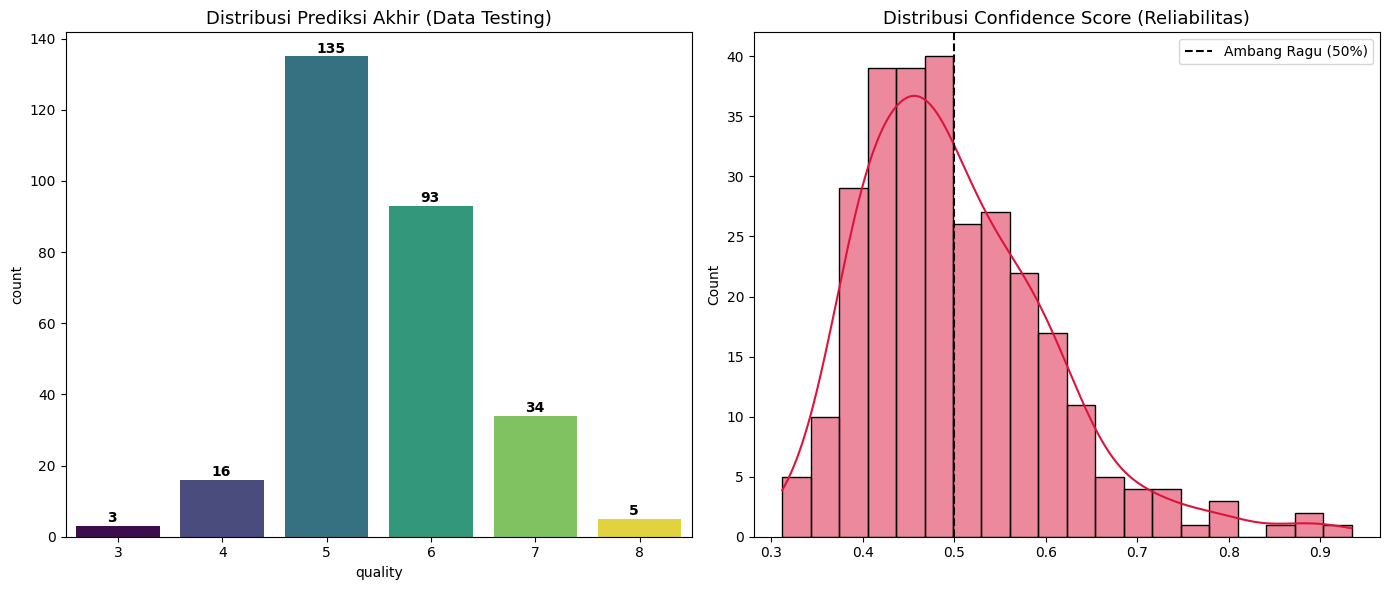


✅ FILE 'hasilprediksi_026.csv' BERHASIL TERBENTUK
✅ Total Record: 286 baris
--------------------------------------------------
>>> STATUS: FORMAT VALID & SIAP SUBMIT KE SISTEM UTS <<<


In [51]:
# =================================================================
# Tahap 9: Prediksi Data Uji (Testing) - FINAL REVISION (NIM 026)
# =================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 9.1 Sync Test Features (Penyelarasan Dimensi Input)
# Menambahkan fitur soft_label (hasil regresi) agar DNN tetap presisi
X_test_dl = X_test_final.copy()
X_test_dl['soft_label'] = reg_teacher.predict(X_test_final)

# 9.2 Robust Inference & Confidence Audit
# Selain mengambil label, kita ambil skor probabilitas untuk audit kualitas prediksi
print("--- Melakukan Inferensi Deep Learning (NIM 026) ---")
y_probs_test = final_dnn.predict(X_test_dl, verbose=0)
y_test_pred_shifted = np.argmax(y_probs_test, axis=1)
y_conf_test = np.max(y_probs_test, axis=1) # Mengambil probabilitas tertinggi per baris

# 9.3 Reverse Scaling
# Mengembalikan indeks internal model (0-5) ke label asli kompetisi (3-8)
min_class = y_train_augmented.min()
y_test_pred = y_test_pred_shifted + min_class

# 9.4 Konstruksi DataFrame Submission (Kaggle Standard)
submission_df = pd.DataFrame({
    'Id': test_id,
    'quality': y_test_pred.astype(int)
})

# 9.5 Audit Distribusi & Prediksi "Berani"
# Cek apakah model berani menebak Kelas 3, 4, atau 8 (Minoritas)
print("\n--- Ringkasan Distribusi Hasil Prediksi ---")
dist_final = submission_df['quality'].value_counts().sort_index()
for q, count in dist_final.items():
    print(f"Kualitas {q:1}: {count:4} sampel (Avg Confidence: {y_conf_test[y_test_pred == q].mean():.2f})")

# 9.6 Visualisasi Distribusi & Confidence Level
plt.figure(figsize=(14, 6))

# Plot Utama: Distribusi Prediksi
plt.subplot(1, 2, 1)
ax = sns.countplot(x='quality', data=submission_df, palette='viridis', hue='quality', legend=False)
plt.title('Distribusi Prediksi Akhir (Data Testing)', fontsize=13)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 1), fontweight='bold')

# Plot Pendukung: Distribusi Keyakinan Model
plt.subplot(1, 2, 2)
sns.histplot(y_conf_test, bins=20, kde=True, color='crimson')
plt.axvline(x=0.5, color='black', linestyle='--', label='Ambang Ragu (50%)')
plt.title('Distribusi Confidence Score (Reliabilitas)', fontsize=13)
plt.legend()

plt.tight_layout()
plt.show()

# 9.7 Export & Final Integrity Check
file_output = 'hasilprediksi_026.csv'
submission_df.to_csv(file_output, index=False)

print(f"\n✅ FILE '{file_output}' BERHASIL TERBENTUK")
print(f"✅ Total Record: {len(submission_df)} baris")
print("-" * 50)

# Final Sanity Check: Memastikan tidak ada label "Ajaib" di luar 3-8
if submission_df['quality'].between(3, 8).all() and not submission_df.isnull().any().any():
    print(">>> STATUS: FORMAT VALID & SIAP SUBMIT KE SISTEM UTS <<<")
else:
    print("⚠️ PERINGATAN: Deteksi nilai di luar rentang atau nilai kosong!")